In [1]:
# imports
import os
import sys
sys.path.append("..")  # add project root
import scipy.io as sio
import importlib
from prog import mlps, featlib, trainer, hlprs
importlib.reload(mlps)
importlib.reload(trainer)
importlib.reload(hlprs)
import Datasets.load_mat_as_flat as lmf
import Datasets.matconv as mc
import torch
import matplotlib.pyplot as plt
import numpy as np

How would we find best TV coeff?

First, we take our original data (keep in mind this data was generated with a numerical solver based on a CHOSEN initial condition with a SPECIFIED curvature)

- ex: take one of the .mat files (burgers.mat)
- Increase the noise until it breaks (say we have N different noise values)
    - Here, "breaking" might mean our loss is above 10e-3 or some other error cutoff
- Take the max noise value (the one before the model broke), and now apply a range of TV coeff values on new models with this max noise value




set error = 0
noise = 0
list = [list of each .mat file's directory]
while (error below cutoff):
    - instantiate model with noise set to previously defined noise
    - train for ~ 40k steps (up to debate how many steps we train)
    - evaluate total model loss
    - save 
    - increase noise

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

max_error = 0.001 # 10e-3

# Data generation settings
path = "../Datasets/data/raw/burgers.mat"
noise=0.0
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432



selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.01
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.1
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

        

c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


* * * * * * * * * * * * * * * 
Training with noise=0.0
step 1000: loss 0.0001
step 2000: loss 0.0001
step 3000: loss 0.0001
step 4000: loss 0.0000
snapshot_comp: with noise=0.000, stride_t=1, stride_x=1
max_abs_diff = 0.0259803
NOISE LEVEL 0.0 DID NOT REACH MAX ERROR
* * * * * * * * * * * * * * * 
Training with noise=0.05
step 1000: loss 0.0296
step 2000: loss 0.0280
step 3000: loss 0.0245
step 4000: loss 0.0262
snapshot_comp: with noise=0.040, stride_t=1, stride_x=1
max_abs_diff = 0.109117
MAX ERROR REACHED AT NOISE LEVEL 0.05


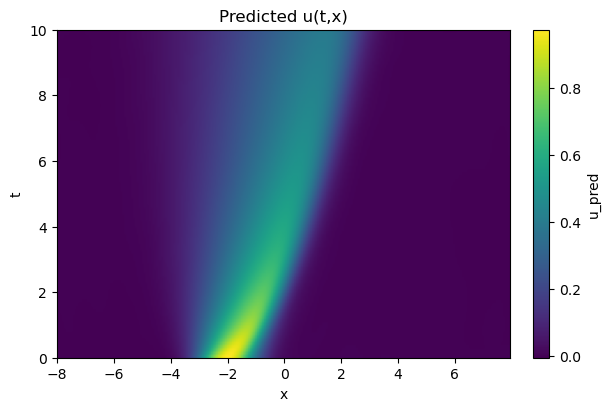

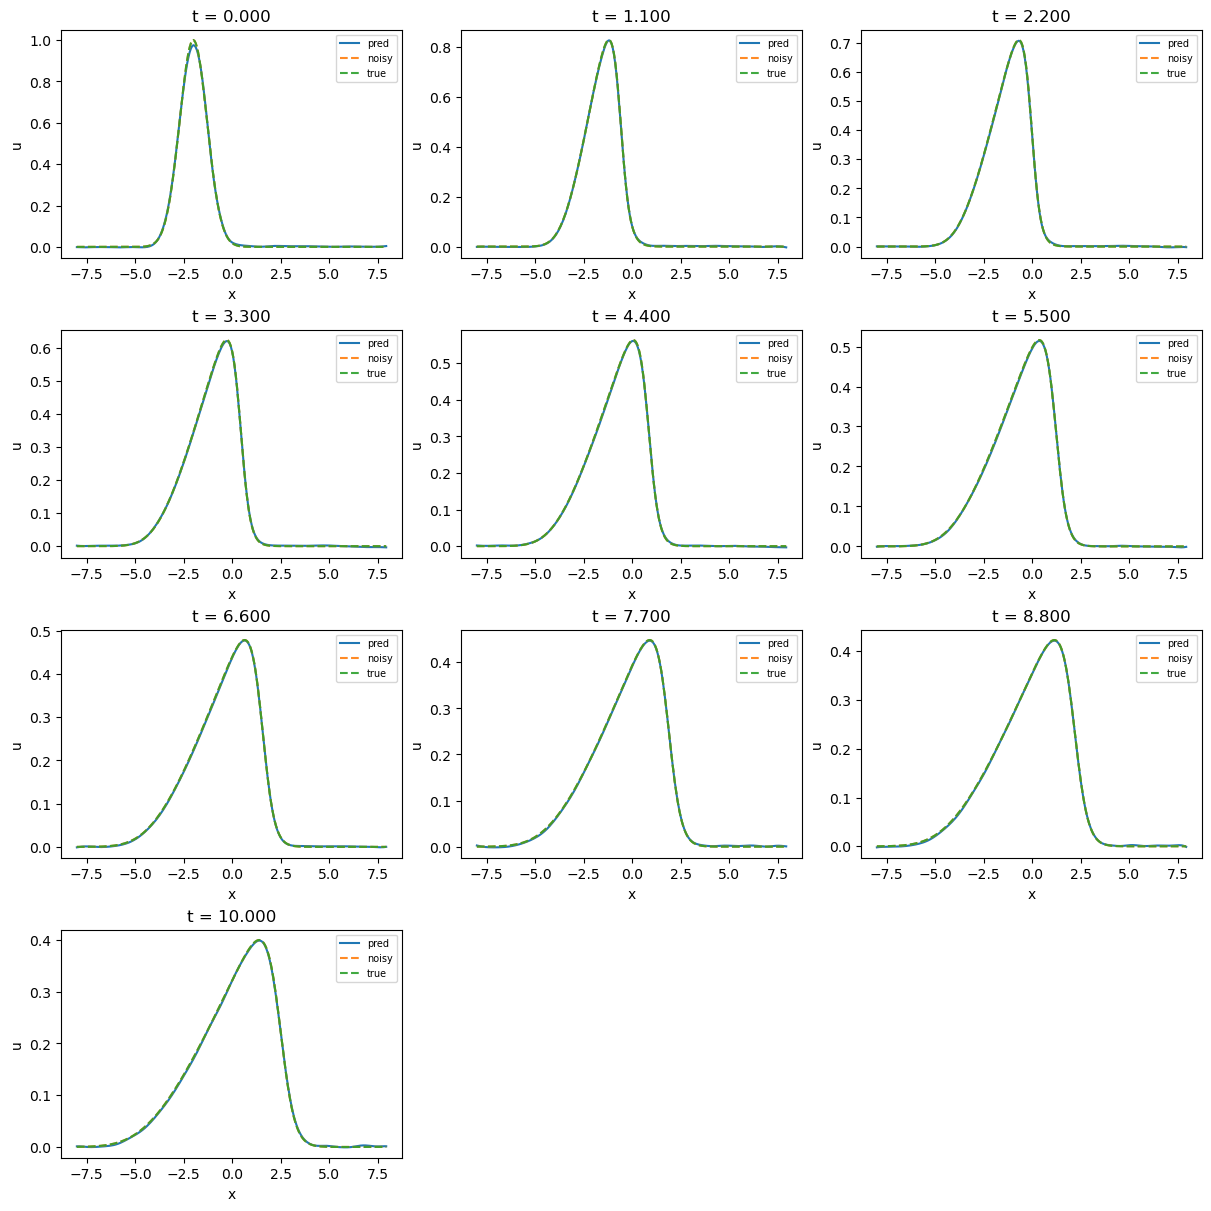

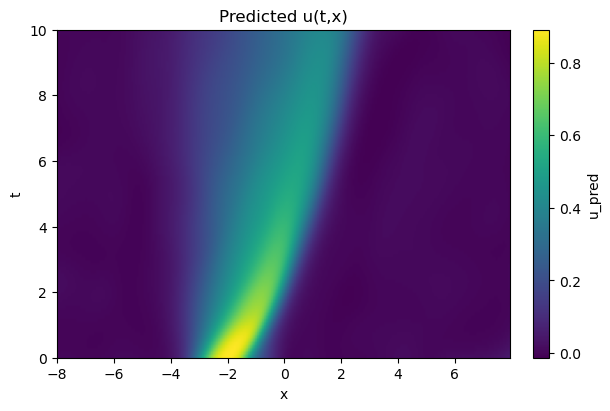

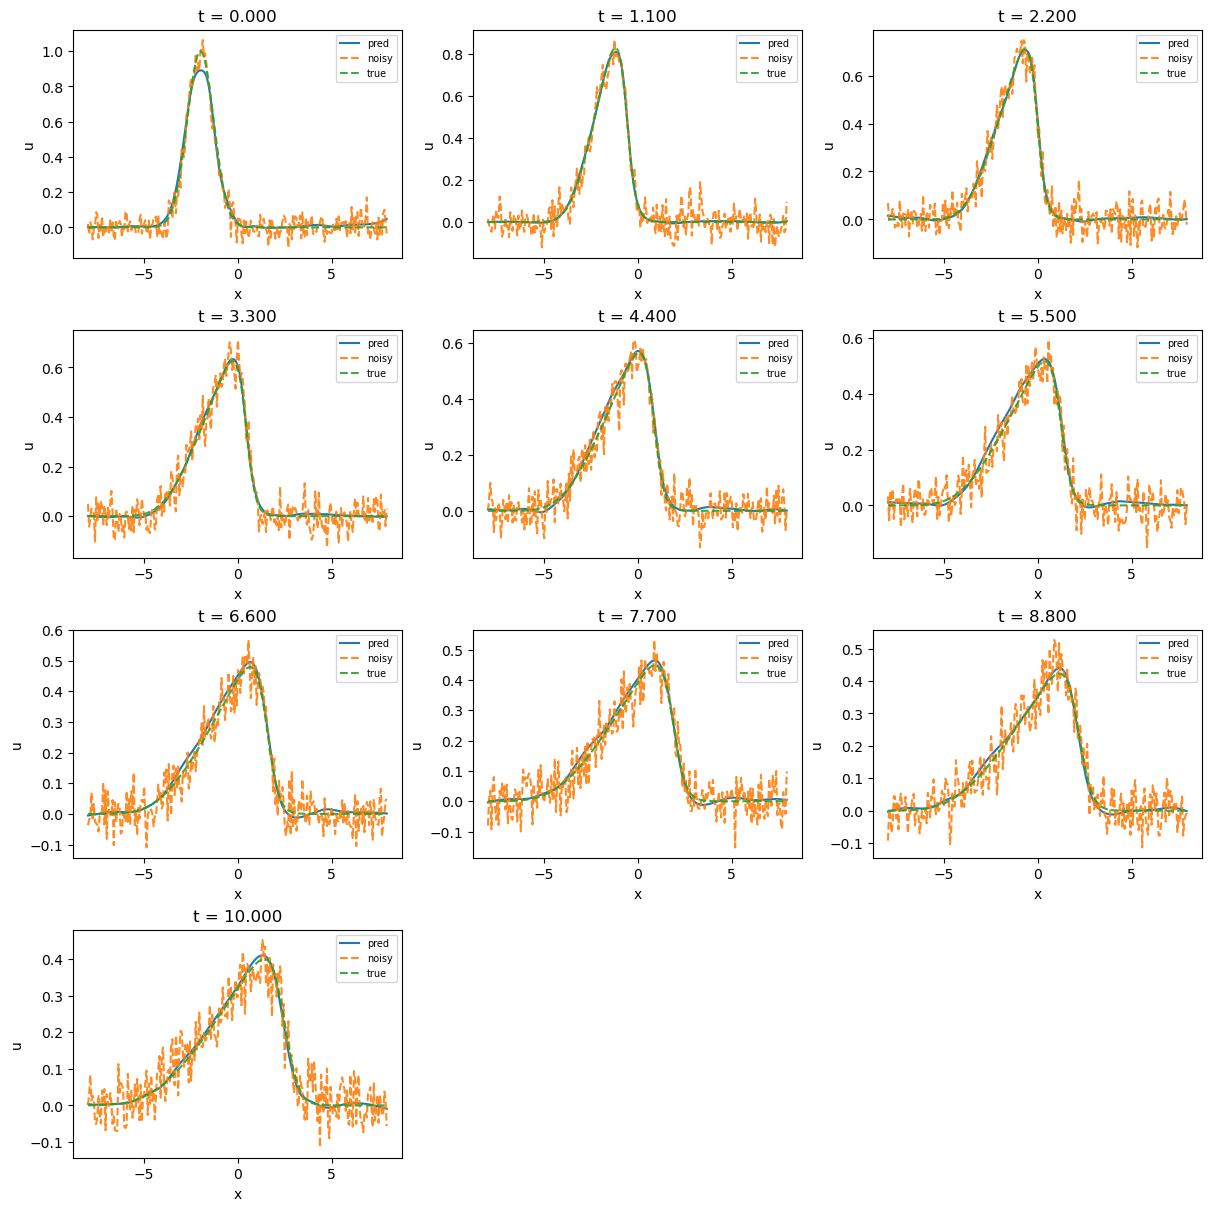

In [6]:
# a little trick so we can access the models after the loop and not have to worry about scope issues
# u_model=mlps.SirenMLP(hidden_layers=3,hidden_size=50)
u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
model_loss = 0

while(True):
    #create dataset with noise level
    partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                            noise_level=noise, 
                                            stride_t=stride_t, 
                                            stride_x=stride_x, 
                                            seed=seed, 
                                            quantile_splits=part_num, 
                                            return_partitions=True)

    t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

    t_torch       = torch.from_numpy(t_np).to(device)
    x_torch       = torch.from_numpy(x_np).to(device)
    y_torch       = torch.from_numpy(y_np).to(device)
    y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)
    
    # instantiate model
    # u_model=mlps.SirenMLP(hidden_layers=3,hidden_size=50)
    u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64)
    v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # default num_layers is 1 for burgers (highest terms are quadratic)
    
    train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
    )
    
    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build
    train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

    # train model
    print("* * * * * * * * * * * * * * * ")
    print(f"Training with noise={noise}")
    for i in range(4000): 
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                            t_torch=t_torch,
                                            x_torch=x_torch,
                                            y_clean=y_torch,
                                            y_noisy=y_noisy_torch)
        out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)

        if (i + 1)%log_every==0:
            print(f'step {i + 1}: loss {out["loss"]:.4f}')
            model_loss = out["loss"]


    hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

    # calculate error
    if max_error <= model_loss: # replace current_error with TOTAL model error
        print(f"MAX ERROR REACHED AT NOISE LEVEL {noise}")
        # save model
        break
    else:
        print(f"NOISE LEVEL {noise} DID NOT REACH MAX ERROR")
        # add noise to data
        noise += 0.05

In [8]:
# reset noise to 0
noise = 0.0

c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


* * * * * * * * * * * * * * * 
Training with noise=0.0
step 1000: loss 0.3513
step 2000: loss 0.3902
step 3000: loss nan
step 4000: loss nan
snapshot_comp: with noise=0.000, stride_t=1, stride_x=1
max_abs_diff = 0.918007
NOISE LEVEL 0.0 DID NOT REACH MAX ERROR
* * * * * * * * * * * * * * * 
Training with noise=0.2
step 1000: loss 0.7119
step 2000: loss 0.8236
step 3000: loss 0.7540
step 4000: loss nan
snapshot_comp: with noise=0.160, stride_t=1, stride_x=1
max_abs_diff = 0.935481
NOISE LEVEL 0.2 DID NOT REACH MAX ERROR
* * * * * * * * * * * * * * * 
Training with noise=0.4
step 1000: loss 1.9941
step 2000: loss 2.0583
step 3000: loss nan
step 4000: loss nan
snapshot_comp: with noise=0.320, stride_t=1, stride_x=1
max_abs_diff = 0.921267
NOISE LEVEL 0.4 DID NOT REACH MAX ERROR
* * * * * * * * * * * * * * * 
Training with noise=0.6000000000000001
step 1000: loss 3.9761
step 2000: loss 4.0818
step 3000: loss 3.9656
step 4000: loss nan
snapshot_comp: with noise=0.480, stride_t=1, stride_x=1

KeyboardInterrupt: 

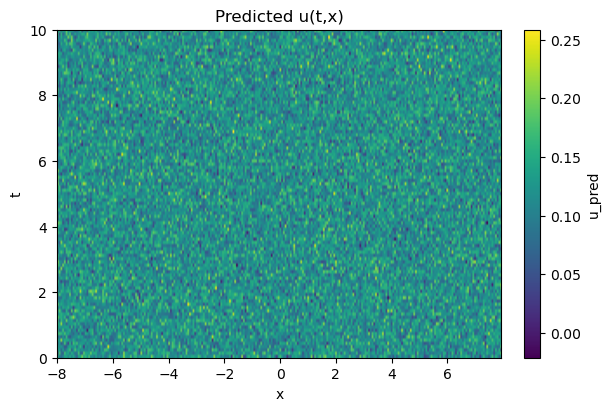

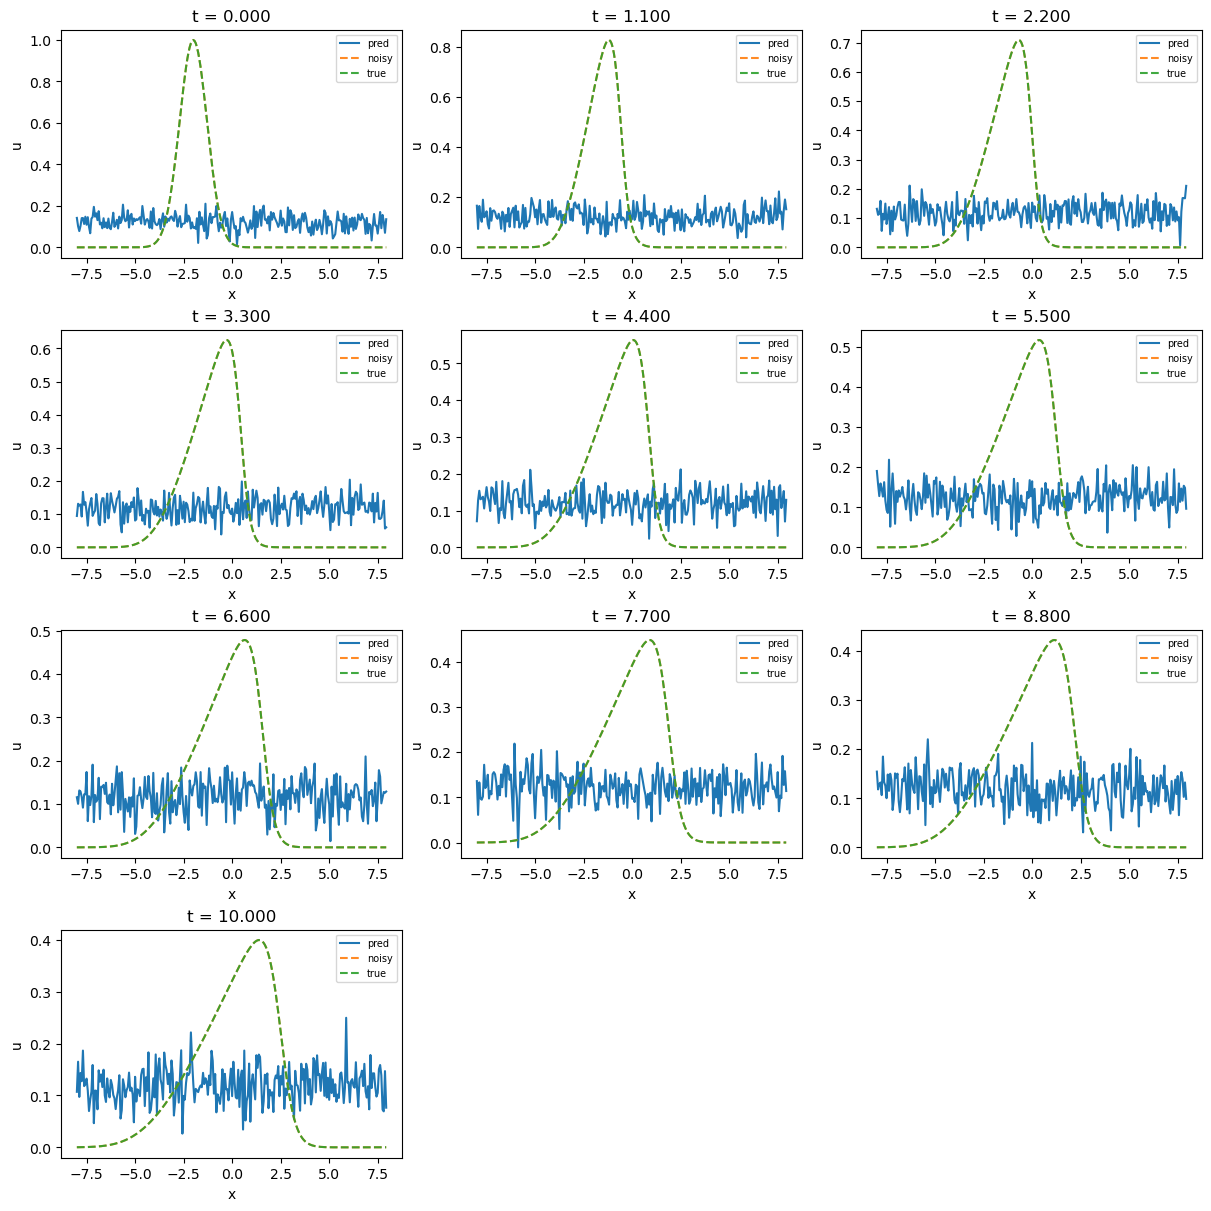

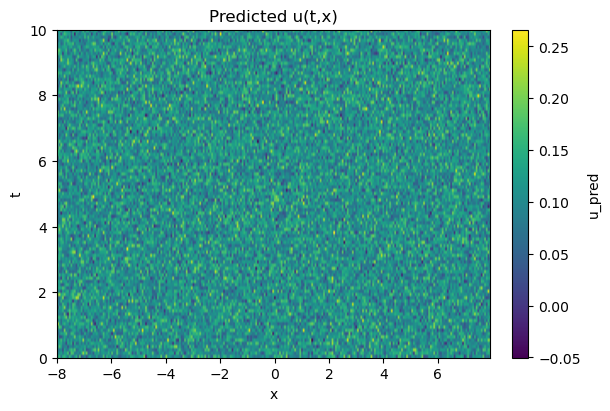

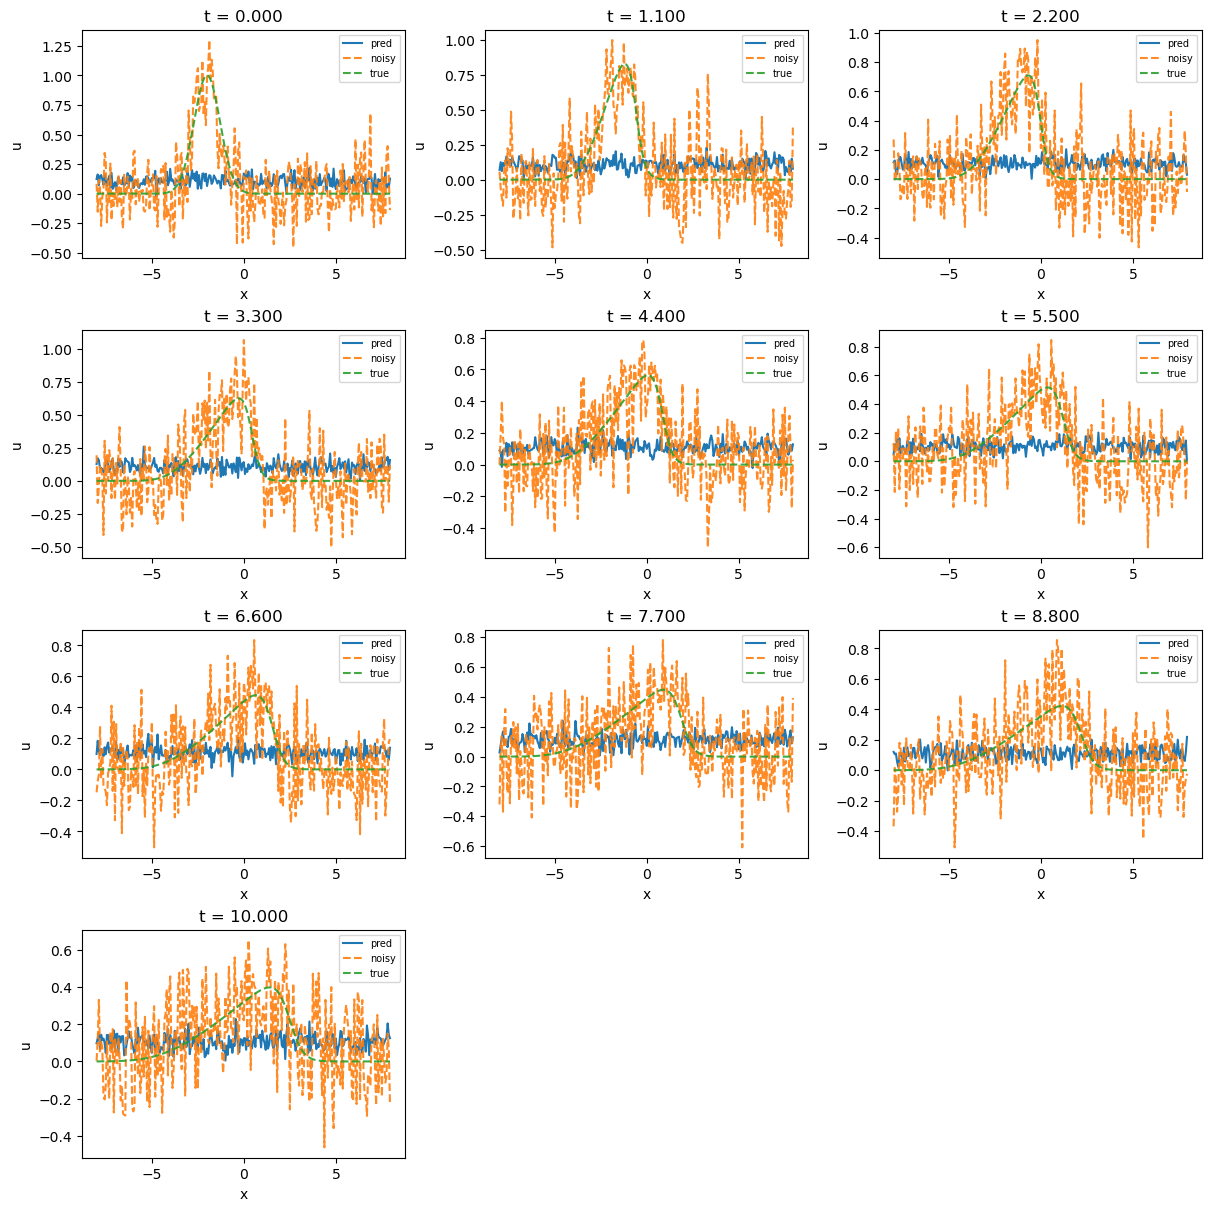

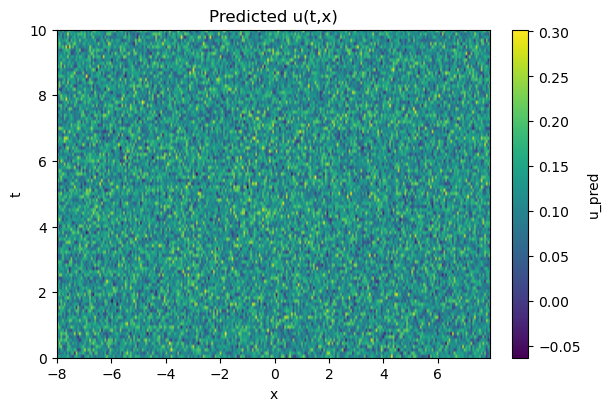

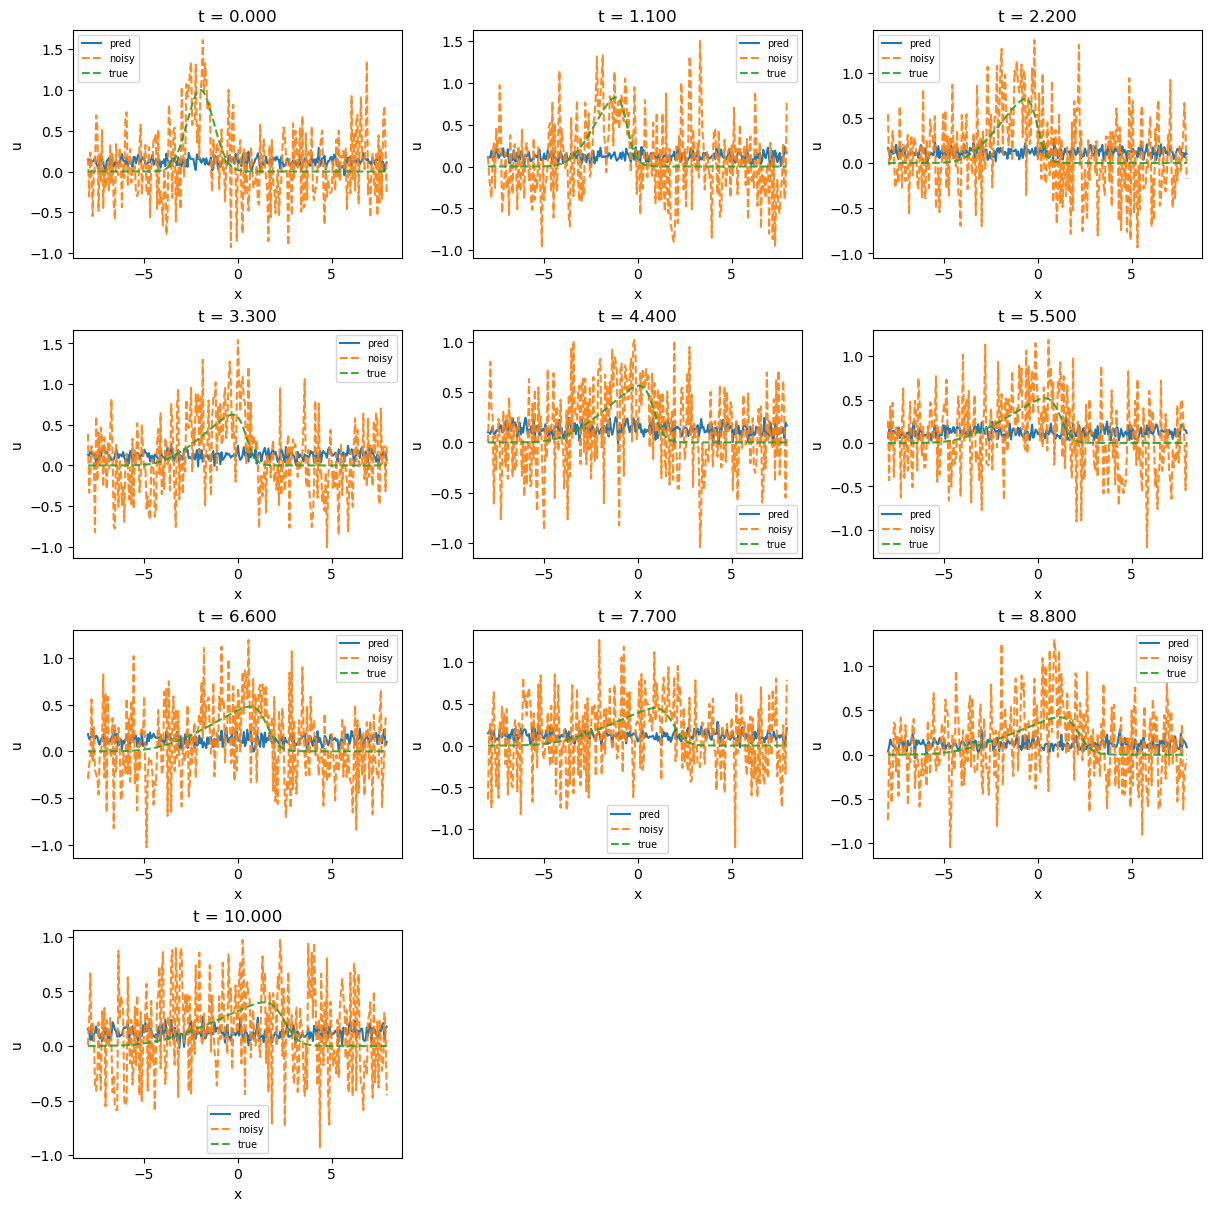

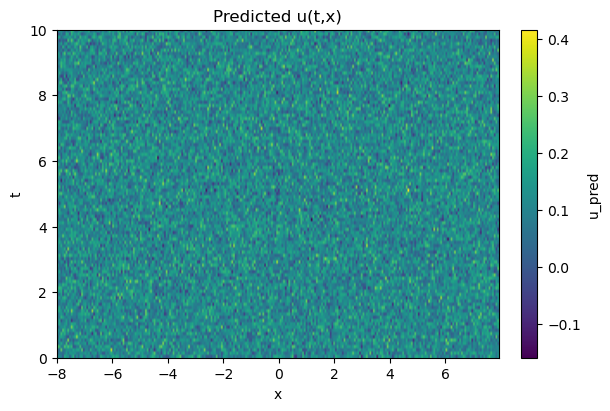

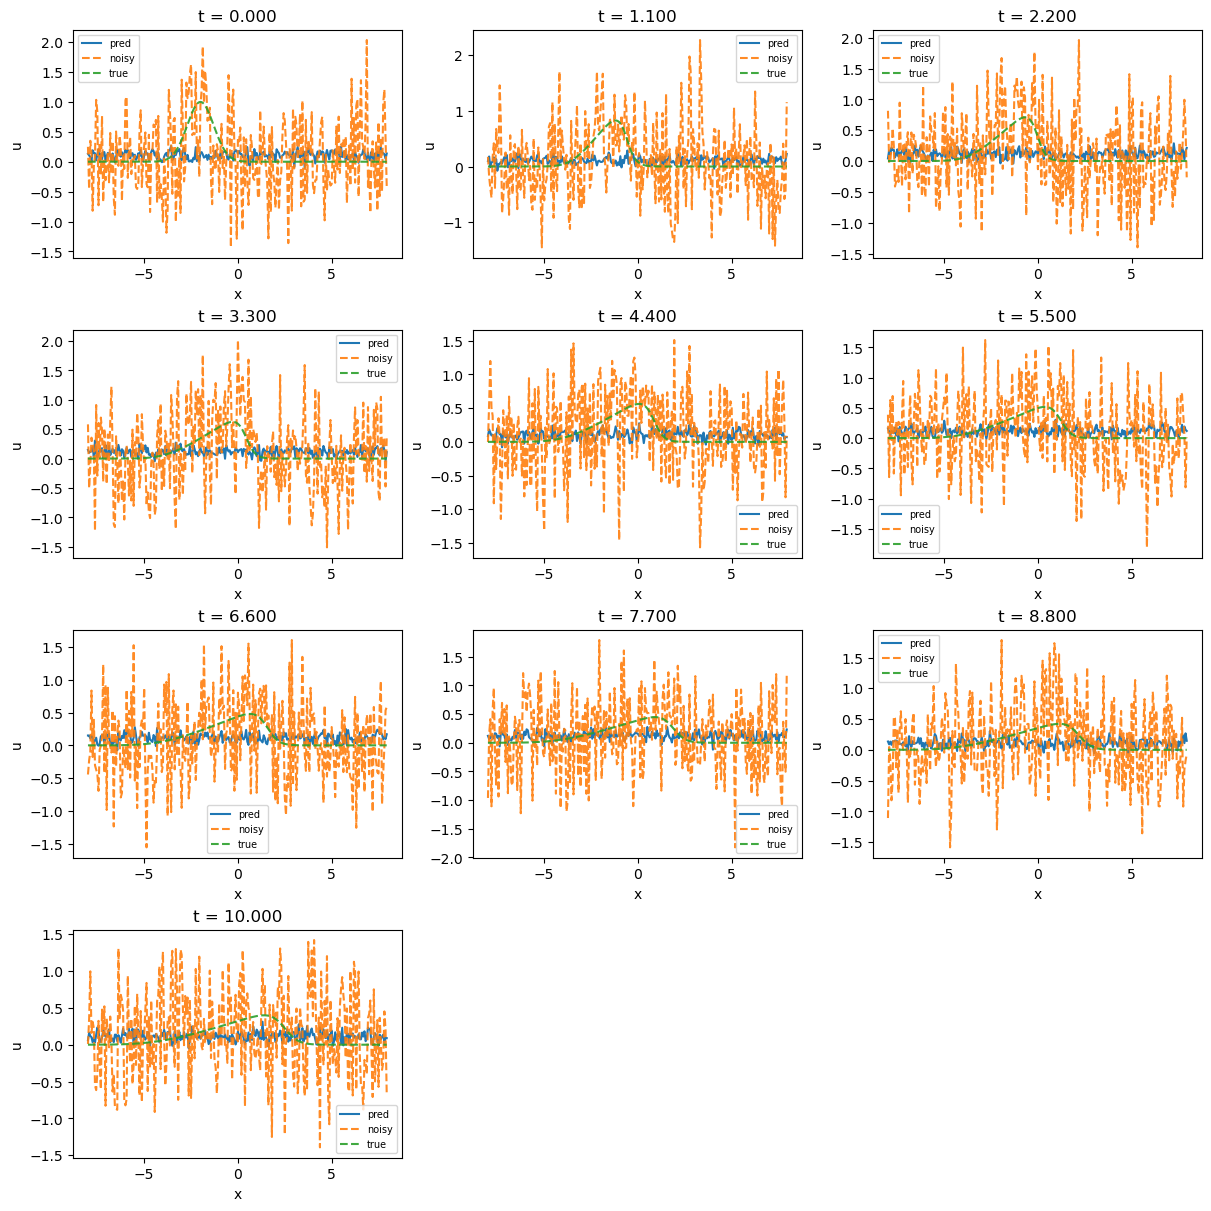

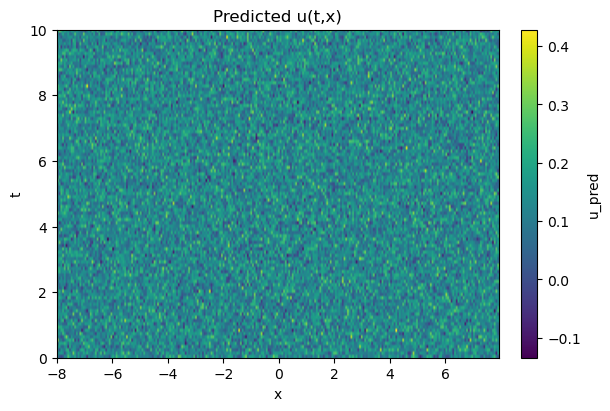

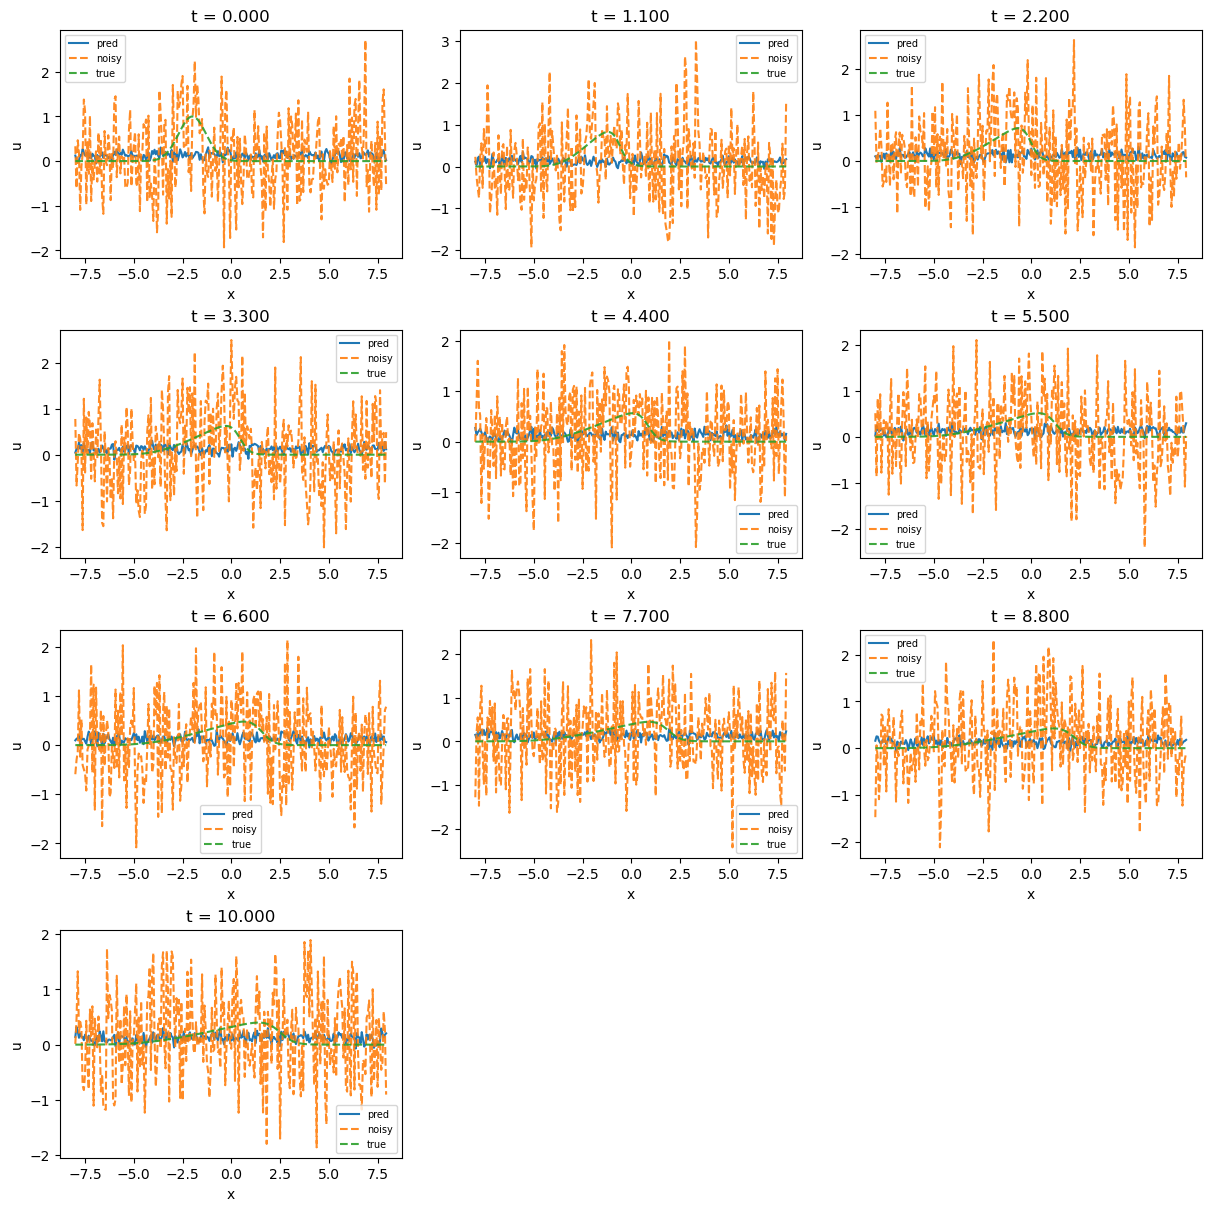

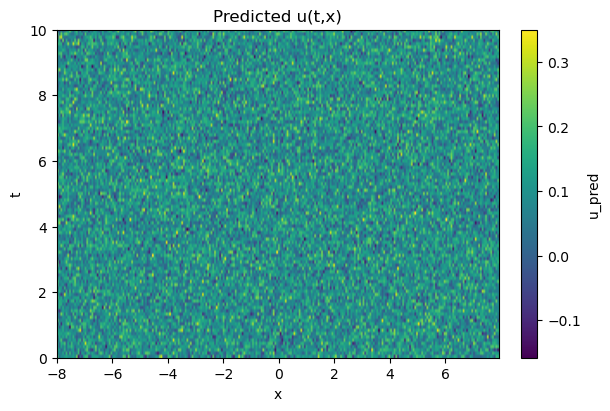

Error in callback <function flush_figures at 0x000001F14A981990> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [9]:
# a little trick so we can access the models after the loop and not have to worry about scope issues
# u_model=mlps.SirenMLP(hidden_layers=3,hidden_size=50)
u_model = mlps.SirenMLP(hidden_layers=3, hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
model_loss = 0

while(True):
    #create dataset with noise level
    partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                            noise_level=noise, 
                                            stride_t=stride_t, 
                                            stride_x=stride_x, 
                                            seed=seed, 
                                            quantile_splits=part_num, 
                                            return_partitions=True)

    t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

    t_torch       = torch.from_numpy(t_np).to(device)
    x_torch       = torch.from_numpy(x_np).to(device)
    y_torch       = torch.from_numpy(y_np).to(device)
    y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)
    
    # instantiate model
    # u_model=mlps.SirenMLP(hidden_layers=3,hidden_size=50)
    u_model = mlps.SirenMLP(hidden_layers=3, hidden_size=64)
    v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # default num_layers is 1 for burgers (highest terms are quadratic)
    
    train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
    )
    
    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build
    train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

    # train model
    print("* * * * * * * * * * * * * * * ")
    print(f"Training with noise={noise}")
    for i in range(4000): 
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                            t_torch=t_torch,
                                            x_torch=x_torch,
                                            y_clean=y_torch,
                                            y_noisy=y_noisy_torch)
        out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)

        if (i + 1)%log_every==0:
            print(f'step {i + 1}: loss {out["loss"]:.4f}')
            model_loss = out["loss"]


    hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

    # calculate error
    if max_error <= model_loss: # replace current_error with TOTAL model error
        print(f"MAX ERROR REACHED AT NOISE LEVEL {noise}")
        # save model
        break
    else:
        print(f"NOISE LEVEL {noise} DID NOT REACH MAX ERROR")
        # add noise to data
        noise += 0.2

In [4]:
noise = 0.0
#create dataset with noise level
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                        noise_level=0.0, 
                                        stride_t=stride_t, 
                                        stride_x=stride_x, 
                                        seed=seed, 
                                        quantile_splits=part_num, 
                                        return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

# instantiate model
# u_model=mlps.SirenMLP(hidden_layers=3,hidden_size=50)
u_model = mlps.SirenMLP(hidden_layers=3, hidden_size=32)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # default num_layers is 1 for burgers (highest terms are quadratic)

train_config=trainer.TrainerConfig(
lr=lr,
lambda_pde=lam_pde, 
lambda_reg=lam_reg,
lambda_tv=lam_tv, 
lambda_data=lam_data, 
selected_derivs=selected_derivs, 
)

ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

# train model
# print("* * * * * * * * * * * * * * * ")
# print(f"Training with noise={noise}")
# for i in range(20000): 
#     t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
#                                         t_torch=t_torch,
#                                         x_torch=x_torch,
#                                         y_clean=y_torch,
#                                         y_noisy=y_noisy_torch)
#     out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)

#     if (i + 1)%log_every==0:
#         print(f'step {i + 1}: loss {out["loss"]:.4f}')
#         model_loss = out["loss"]


# hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


c:\Users\Ethan\anaconda3\envs\pythonProject\lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


* * * * * * * * * * * * * * * 
Training with noise=0.0
step 1000: loss 0.3748
step 2000: loss 0.3161
step 3000: loss 0.3444
step 4000: loss 0.3164
step 5000: loss 0.3462
step 6000: loss 0.3480
step 7000: loss 0.3381
step 8000: loss 0.3011
step 9000: loss 0.3258
step 10000: loss 0.2987
step 11000: loss 0.3519
step 12000: loss 0.3565
step 13000: loss 0.3443
step 14000: loss 0.3292
step 15000: loss 0.3163
step 16000: loss 0.3441
step 17000: loss 0.2951
step 18000: loss 0.3304
step 19000: loss 0.2998
step 20000: loss 0.3080
snapshot_comp: with noise=0.000, stride_t=1, stride_x=1
max_abs_diff = 0.880756


()

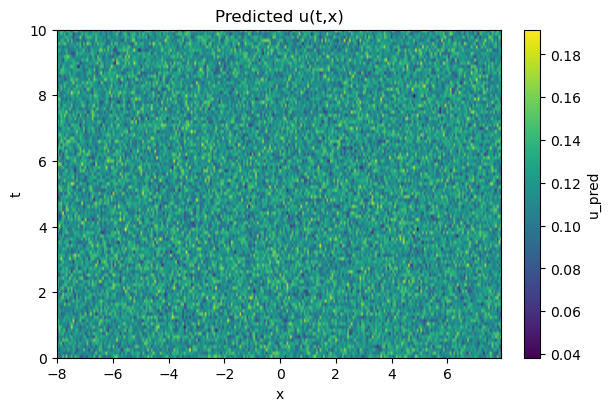

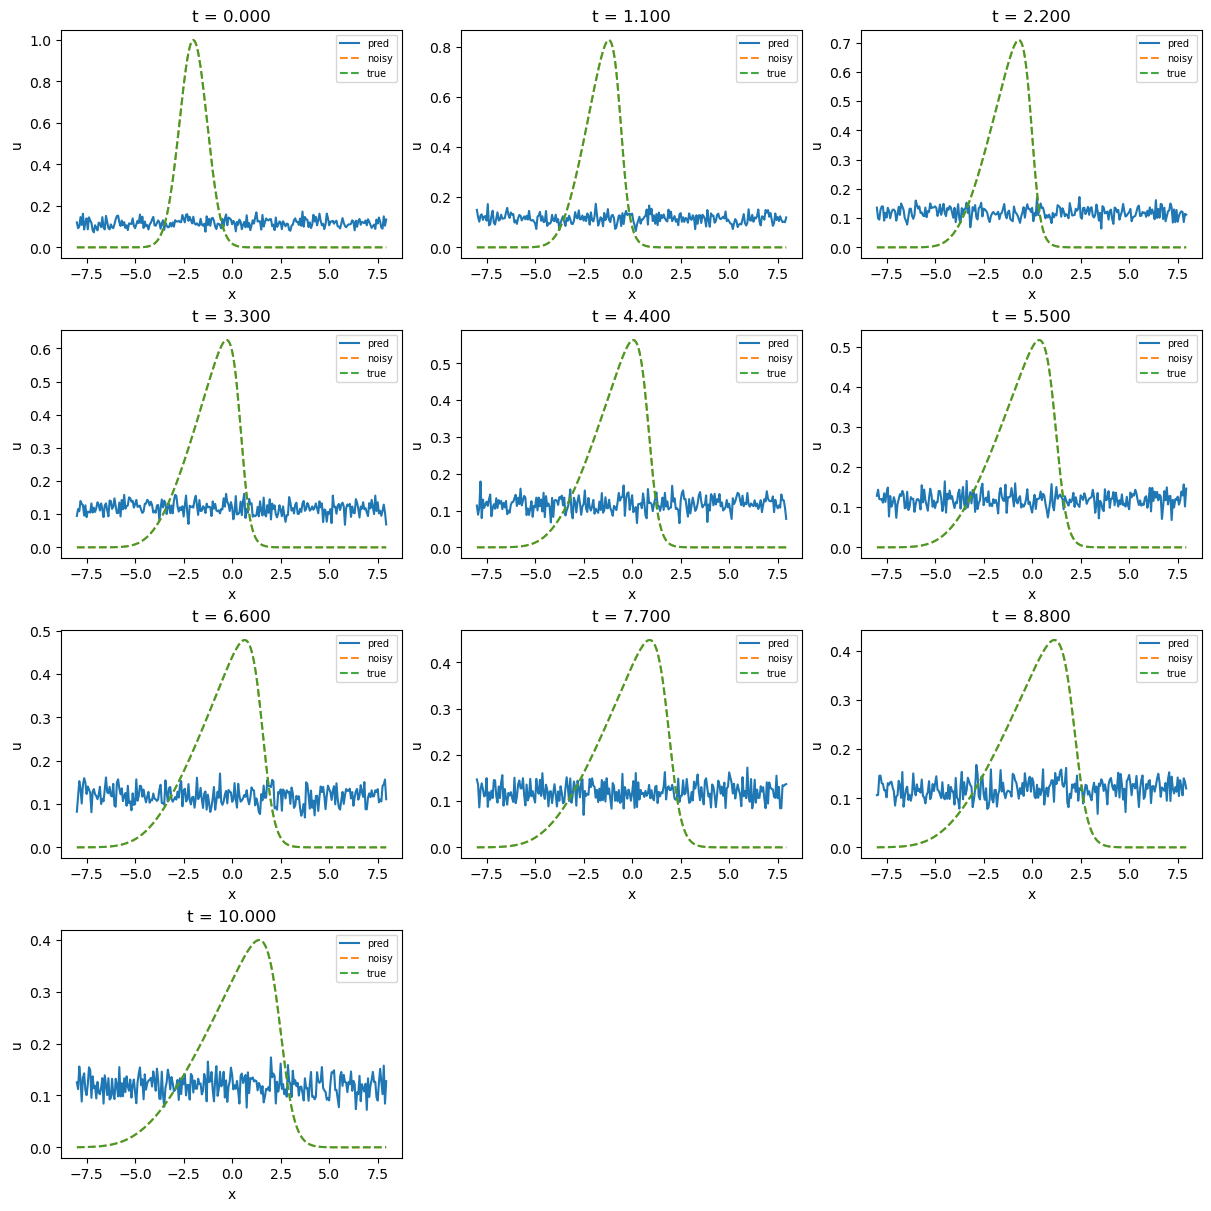

In [ ]:
# trying again to see if we can just fit the data (lam_pde=0)
lam_pde=0.0

#instantiate new model (not pretrained)
u_model = mlps.SirenMLP(hidden_layers=3, hidden_size=32)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v model since we're not using PDE loss

train_config=trainer.TrainerConfig(
lr=lr,
lambda_pde=lam_pde, 
lambda_reg=lam_reg,
lambda_tv=lam_tv, 
lambda_data=lam_data, 
selected_derivs=selected_derivs, 
)

ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

# # train model
# print("* * * * * * * * * * * * * * * ")
# print(f"Training with noise={noise}")
# for i in range(20000): 
#     t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
#                                         t_torch=t_torch,
#                                         x_torch=x_torch,
#                                         y_clean=y_torch,
#                                         y_noisy=y_noisy_torch)
#     out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)

#     if (i + 1)%log_every==0:
#         print(f'step {i + 1}: loss {out["loss"]:.4f}')
#         model_loss = out["loss"]


# hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]